In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/SzymonNowakowski/Machine-Learning-2025L/master/PCA_three_clusters_data.csv"
df = pd.read_csv(url)

print("Column Names:")
print(df.columns)

print("\nColumn Types:")
print(df.dtypes)

print("\nFirst five 5 rows:")
print(df.head())

print("\nCounts of each class in the frame: ")
print(df['class'].value_counts())
print("\nTotal length: ", df.shape[0])



Column Names:
Index(['x', 'y', 'z', 'class'], dtype='object')

Column Types:
x        float64
y        float64
z        float64
class      int64
dtype: object

First five 5 rows:
          x         y          z  class
0  0.647689 -0.138264   3.512299      0
1 -0.234137 -0.234153  10.769447      0
2 -0.469474  0.767435  11.166721      0
3 -0.465730 -0.463418   3.836479      0
4 -1.724918 -1.913280   1.710932      0

Counts of each class in the frame: 
class
0    100
1    100
2    100
Name: count, dtype: int64

Total length:  300


**Primary Question**

Perform PCA on the provided dataset to find the two principal components and visualize the data in a 2D plot using these components.

Compare this PCA plot with the following 2D plots of the original data:



1.  $x$ vs $y$
2.  $x$ vs $z$
3.  $y$ vs $z$

Does PCA improve the separation from different clusters compared to the original feature spaces? Explain why.

**Secondary Question**

Remember: before applying PCA, standarize the data so that each feature has a mean $0$ and variance $1$. Why is standardization necessary before applying PCA?

Explain how differences in scale among features can impact the principal component directions.


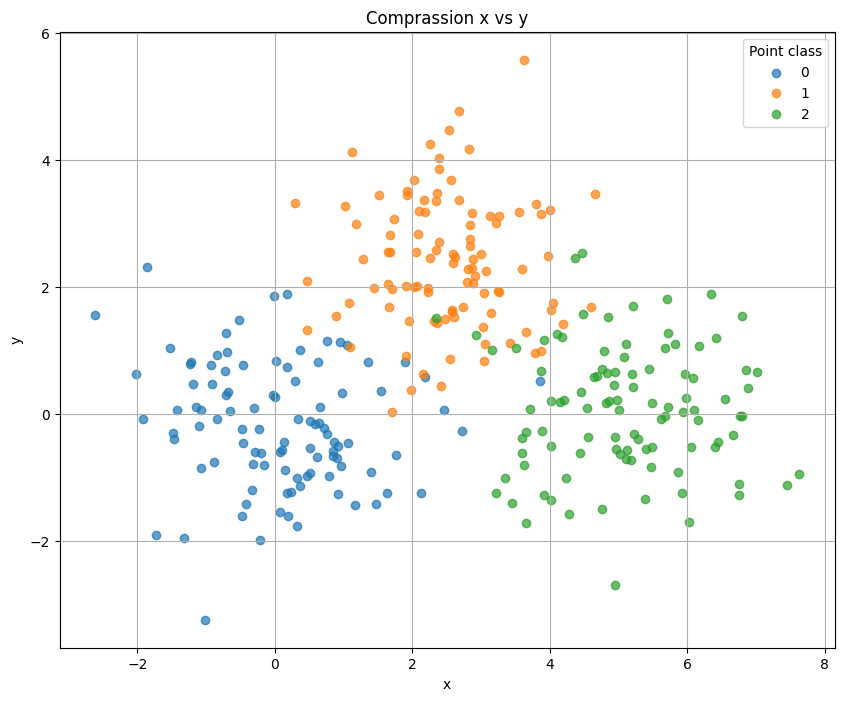

In [3]:
import matplotlib.pyplot as plt
import numpy as np

X, y = df.drop(columns='class').to_numpy(), df['class'].to_numpy()
m, n = X.shape

n_classes = np.unique(y).shape[-1]
coordinates = ((0, 1), (0, 2), (1, 2))
label_map = ('x', 'y', 'z')


def visualize_coordinates(c1, c2):
  plt.figure(figsize=(10, 8))
  for j in range(n_classes):
    plt.scatter(X[y == j, c1], X[y == j, c2], label=str(j), alpha=0.7)

  plt.xlabel(f"{label_map[c1]}")
  plt.ylabel(f"{label_map[c2]}")
  plt.title(f"Comprassion {label_map[c1]} vs {label_map[c2]}")
  plt.legend(title="Point class")
  plt.grid(True)
  plt.show()

visualize_coordinates(*coordinates[0])

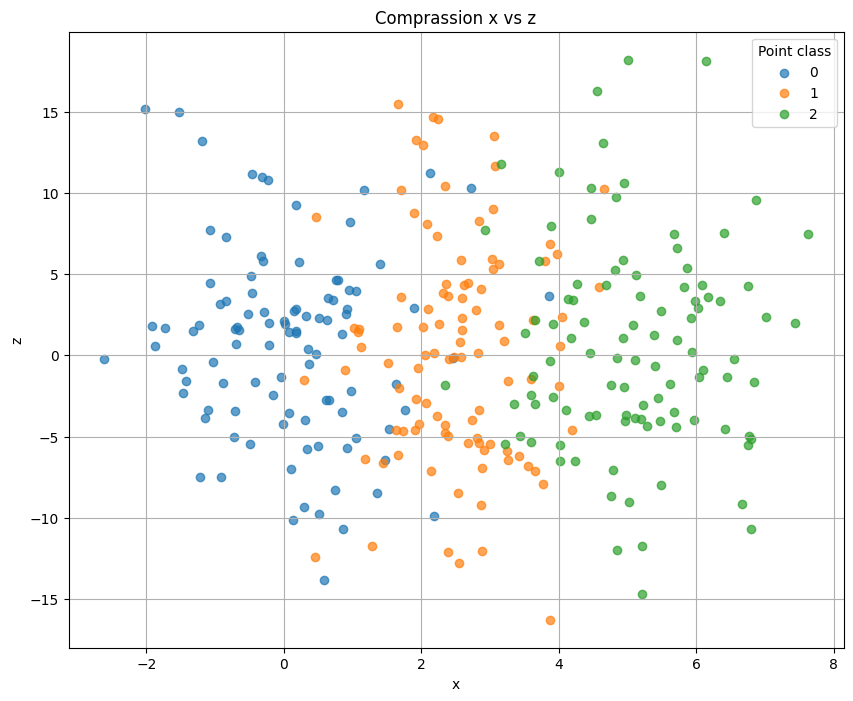

In [4]:
visualize_coordinates(*coordinates[1])

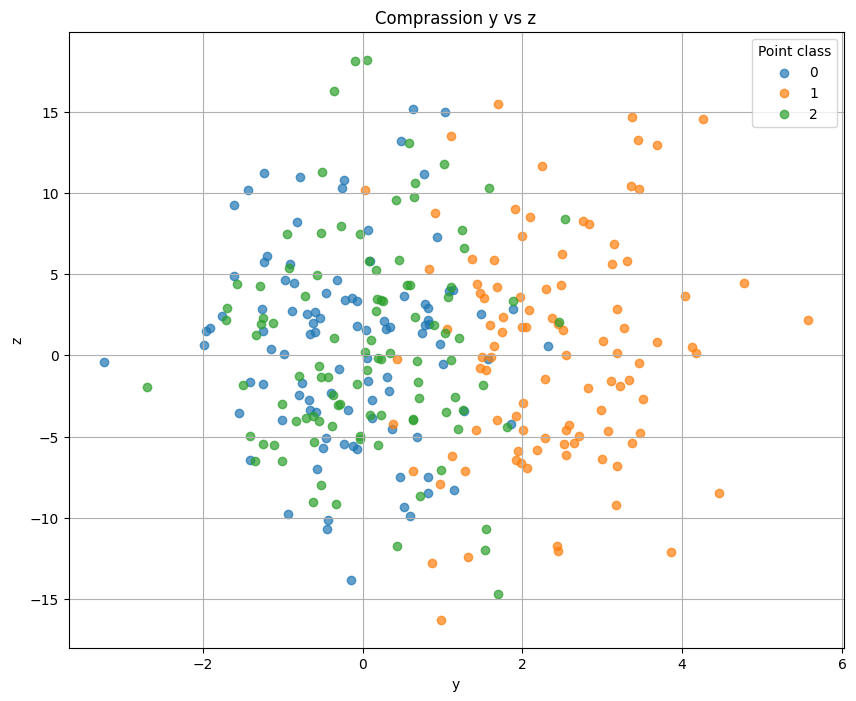

In [5]:
visualize_coordinates(*coordinates[2])

In [6]:
print("Coordinates standard deviation:")
std = np.std(X, axis=0)
print(std)

Coordinates standard deviation:
[2.29653432 1.52685818 6.31597484]


In [7]:
mu = np.mean(X, axis=0)
Xc = X - mu

U, Sigma, VT = np.linalg.svd(Xc)
variance_estimators = Sigma**2 / (m - 1)

XV = Xc @ VT.T

print("\nX projected on V (first 5 rows):")
print(XV[:5, :])

print("\n(random 5 rows):")
print(XV[np.random.randint(0, m, 5),:])

print("\nVariance estimators:")
print(variance_estimators)

print("\n Cumulate explained percentage variance:")
print(np.cumsum(variance_estimators)/sum(variance_estimators))




X projected on V (first 5 rows):
[[ -3.05824099  -1.91725482   0.82146253]
 [-10.3243579   -2.72463364   0.88995653]
 [-10.72497785  -2.91386929  -0.12003466]
 [ -3.39408622  -3.03969616   1.10047991]
 [ -1.28096705  -4.3807283    2.49402474]]

(random 5 rows):
[[ 3.94224316 -1.80913142  1.27156193]
 [ 5.0711597  -0.90149313 -1.83110324]
 [-1.4433012  -0.21490651 -1.6993349 ]
 [-8.55602737  0.62408629 -1.11664171]
 [ 4.40670908  2.5865089   0.23070054]]

Variance estimators:
[40.02899084  5.29281251  2.33395321]

 Cumulate explained percentage variance:
[0.83996129 0.95102474 1.        ]


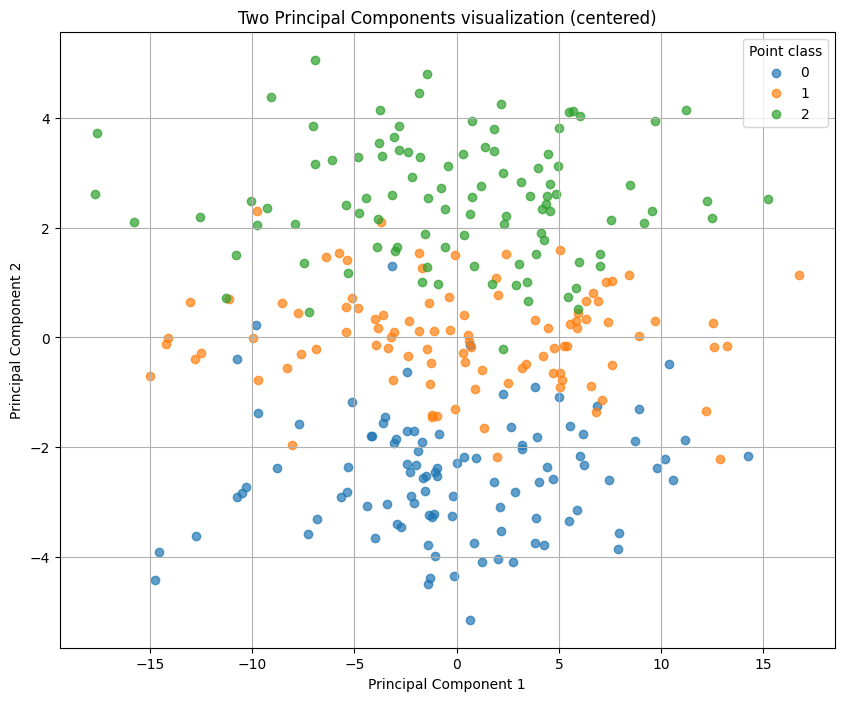

In [8]:
plt.figure(figsize=(10, 8))
for j in range(n_classes):
  plt.scatter(XV[y == j, 0], XV[y == j, 1], label=str(j), alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Two Principal Components visualization (centered)")
plt.legend(title="Point class")
plt.grid(True)
plt.show()


We can see that the **first principal component explains most variance of the data** about $.84$. However, the visualization shows that the **clusters are mainly separated along the second principal component**, which explains only about $.11$ of the variance.

The **variance estimator for the first component is about eight times larger than for the second component and about twenty times larger than for the third component**.

To reduce the influence of different variable scales, we now standardize the data.

In [9]:
Xstd = (X - mu)/std

U, Sigma, VT = np.linalg.svd(Xstd)
variance_estimators = Sigma**2 / (m - 1)

XV = Xstd @ VT.T

print("\nX projected on V (first 5 rows):")
print(XV[:5, :])

print("\n(random 5 rows):")
print(XV[np.random.randint(0, m, 5),:])

print("\n Cumulate explained percentage variance:")
print(np.cumsum(variance_estimators)/sum(variance_estimators))


X projected on V (first 5 rows):
[[ 1.12582206 -0.05986874 -0.0309145 ]
 [ 1.89368654 -0.95808305  0.24333978]
 [ 1.61886158 -1.39907438 -0.17470912]
 [ 1.61654666  0.01318696 -0.22298896]
 [ 2.41865284  0.83294294 -0.20878659]]

(random 5 rows):
[[-0.5808536   0.15560099 -1.01920792]
 [ 0.4273431  -1.5351305   0.87112042]
 [-0.55760091 -0.02474728  1.26193483]
 [-0.41746187 -1.15569048 -0.35916444]
 [ 0.01154483  1.19358912  1.34776762]]

 Cumulate explained percentage variance:
[0.34722276 0.68164111 1.        ]


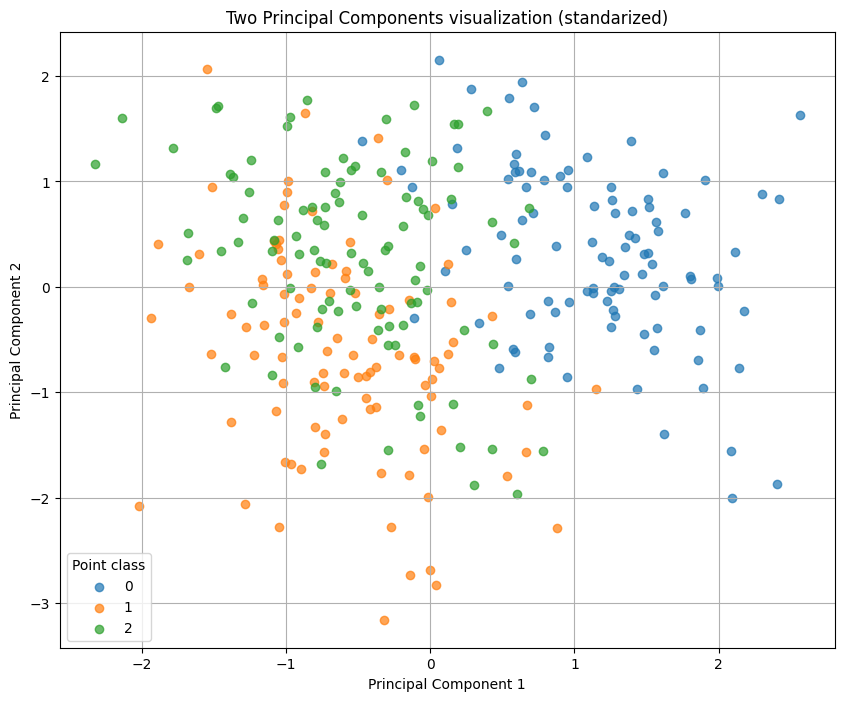

In [10]:
plt.figure(figsize=(10, 8))
for j in range(n_classes):
  plt.scatter(XV[y == j, 0], XV[y == j, 1], label=str(j), alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Two Principal Components visualization (standarized)")
plt.legend(title="Point class")
plt.grid(True)
plt.show()

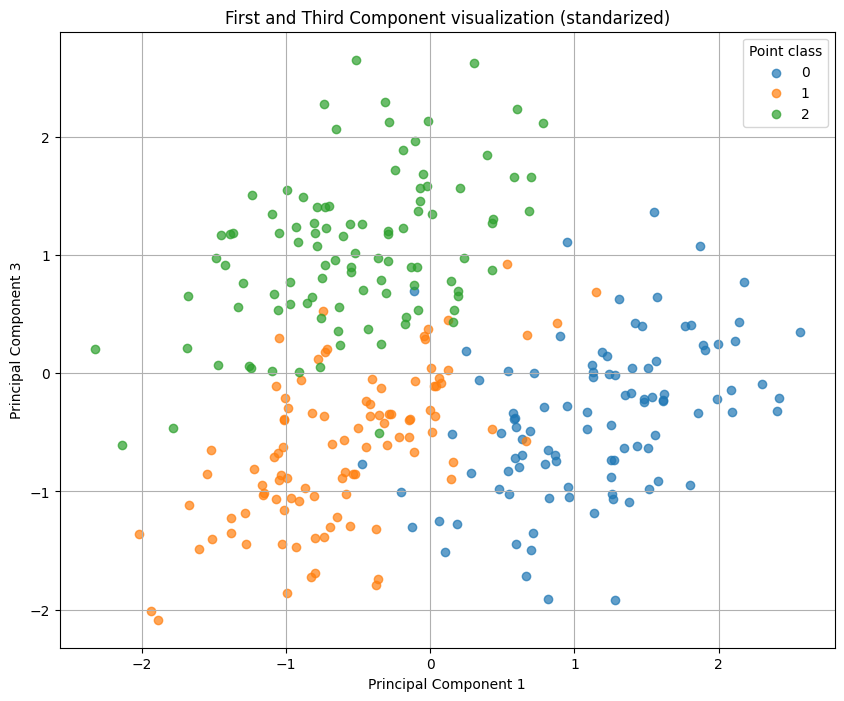

In [11]:
plt.figure(figsize=(10, 8))
for j in range(n_classes):
  plt.scatter(XV[y == j, 0], XV[y == j, 2], label=str(j), alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 3")
plt.title("First and Third Component visualization (standarized)")
plt.legend(title="Point class")
plt.grid(True)
plt.show()

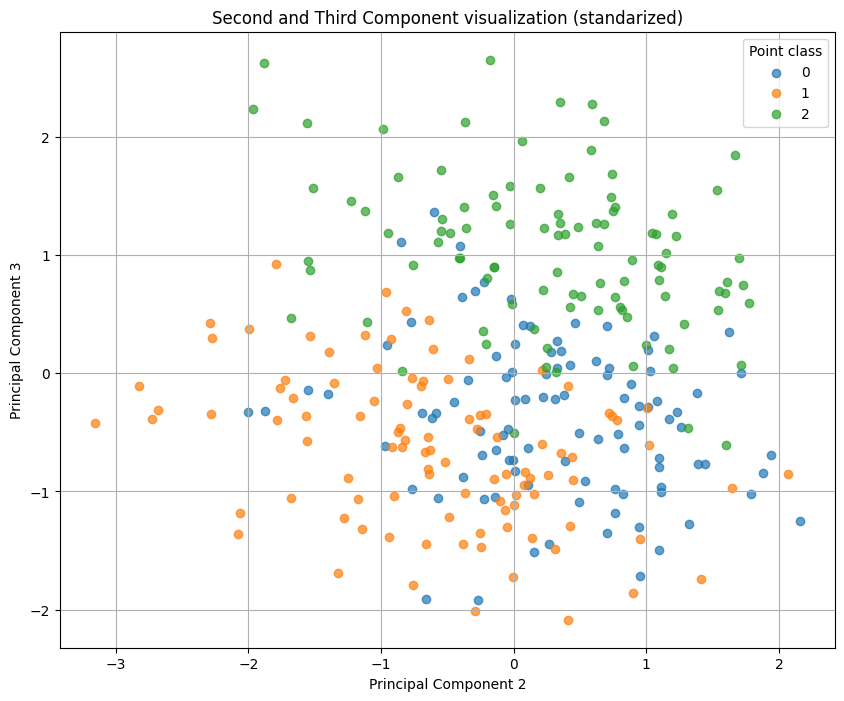

In [12]:
plt.figure(figsize=(10, 8))
for j in range(n_classes):
  plt.scatter(XV[y == j, 1], XV[y == j, 2], label=str(j), alpha=0.7)

plt.xlabel("Principal Component 2")
plt.ylabel("Principal Component 3")
plt.title("Second and Third Component visualization (standarized)")
plt.legend(title="Point class")
plt.grid(True)
plt.show()

**TL;DR**

**Primary Question**

After applying PCA, **the variance is distributed relatively evenly among the three principal components** ($.35$, $.33$, $.32$). This means that **no two-dimensional linear subspace dominates in terms of information content**, and **reducing the data to two dimensions would still discard a non-negligible amount of variance**.

Compared to the original feature plots, **PCA does not improve cluster separation in this dataset**. This is because **PCA** is an unsupervised dimensionality reduction method that **maximizes explained variance, not cluster or class separability**.

**Secondary Question**

**Standardization is necessary before applying PCA when the features have different scales**. PCA identifies directions that maximize the variance of the data, so features with larger numerical ranges or variances can dominate the principal components.

In the centered data (**first case**), the first principal component explained about $.84$ of the total variance, and the first two components explained $.94$. However, this **result was largely driven by the feature with the largest variance**. After standardization, the variance became more evenly distributed across the principal components, indicating that each feature contributes more equally to the PCA.

Therefore, **standardization ensures that PCA captures the underlying relationships between variables rather than being dominated by scale differences**.
